# Actividad - Proyecto práctico

> **Grupo 5 — Entorno asignado: `Enduro-v0`** · *(versión rápida: presupuesto reducido, ~5 h por propuesta)*

> La actividad se desarrollará en grupos pre-definidos de 4 alumnos. Se debe indicar los nombres en orden alfabético (de apellidos). Recordad que esta actividad se corresponde con un 30% de la nota final de la asignatura. Se debe entregar entregar el trabajo en la presente notebook.
*   Alumno 1: Cadena Cedano, Juan David Alejandro
*   Alumno 2: Castañeda Lozano, Carlos Andrés
*   Alumno 3: Jaramillo Rincón, Luis Alejandro

Link de Github: https://github.com/jdalejandro91/rl-project

---
## **PARTE 1** - Instalación y requisitos previos

> Las prácticas han sido preparadas para poder realizarse en el entorno de trabajo de Google Colab. Sin embargo, esta plataforma presenta ciertas incompatibilidades a la hora de visualizar la renderización en gym. Por ello, para obtener estas visualizaciones, se deberá trasladar el entorno de trabajo a local. Por ello, el presente dosier presenta instrucciones para poder trabajar en ambos entornos. Siga los siguientes pasos para un correcto funcionamiento:
1.   **LOCAL:** Preparar el enviroment, siguiendo las intrucciones detalladas en la sección *1.1.Preparar enviroment*.
2.  **AMBOS:** Modificar las variables "mount" y "drive_mount" a la carpeta de trabajo en drive en el caso de estar en Colab, y ejecturar la celda *1.2.Localizar entorno de trabajo*.
3. **COLAB:** se deberá ejecutar las celdas correspondientes al montaje de la carpeta de trabajo en Drive. Esta corresponde a la sección *1.3.Montar carpeta de datos local*.
4.  **AMBOS:** Instalar las librerías necesarias, siguiendo la sección *1.4.Instalar librerías necesarias*.


---
### 1.1. Preparar enviroment (solo local)



> Para preparar el entorno de trabajo en local, se han seguido los siguientes pasos:
1. En Windows, puede ser necesario instalar las C++ Build Tools. Para ello, siga los siguientes pasos. Alternativamente puedes utilizar WSL2: https://towardsdatascience.com/how-to-install-openai-gym-in-a-windows-environment-338969e24d30.
2. Instalar Anaconda
3. Siguiendo el código que se presenta comentado en la próxima celda: Crear un enviroment, cambiar la ruta de trabajo, e instalar librerías básicas.


```
conda create --name miar_rl python=3.8
conda activate miar_rl
cd "PATH_TO_FOLDER"
conda install git
pip install jupyter
```


4. Abrir la notebook con *jupyter-notebook*.



```
jupyter-notebook
```


---
### 1.2. Localizar entorno de trabajo: Google colab o local

In [1]:
mount='/content/gdrive'
drive_root = mount + "/My Drive/08_MIAR/actividades/proyecto practico v2"

try:
  from google.colab import drive
  IN_COLAB=True
except:
  IN_COLAB=False

---
### 1.3. Montar carpeta de datos local (solo Colab)

In [2]:
# Switch to the directory on the Google Drive that you want to use
import os
if IN_COLAB:
  print("We're running Colab")

  if IN_COLAB:
    # Mount the Google Drive at mount
    print("Colab: mounting Google drive on ", mount)

    drive.mount(mount)

    # Create drive_root if it doesn't exist
    create_drive_root = True
    if create_drive_root:
      print("\nColab: making sure ", drive_root, " exists.")
      os.makedirs(drive_root, exist_ok=True)

    # Change to the directory
    print("\nColab: Changing directory to ", drive_root)
    %cd $drive_root
# Verify we're in the correct working directory
%pwd
print("Archivos en el directorio: ")
print(os.listdir())

We're running Colab
Colab: mounting Google drive on  /content/gdrive
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

Colab: making sure  /content/gdrive/My Drive/08_MIAR/actividades/proyecto practico v2  exists.

Colab: Changing directory to  /content/gdrive/My Drive/08_MIAR/actividades/proyecto practico v2
/content/gdrive/My Drive/08_MIAR/actividades/proyecto practico v2
Archivos en el directorio: 
[]


---
### 1.4. Instalar librerías necesarias

In [3]:
if IN_COLAB:
  %pip install tensorflow==2.18.0
  %pip install tf-keras==2.18.0
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install keras-rl2==1.0.5
  # El Colab actual trae un jax que pide ml_dtypes>=0.5, pero TF 2.18 instala la
  # 0.4.x. Como no usamos jax, lo desinstalamos para que no falle al importar TF.
  %pip uninstall -y jax jaxlib
else:
  %pip install gym==0.17.3
  %pip install git+https://github.com/Kojoley/atari-py.git
  %pip install pyglet==1.5.0
  %pip install h5py==3.1.0
  %pip install Pillow==9.5.0
  %pip install keras-rl2==1.0.5
  %pip install Keras==2.2.4
  %pip install tensorflow==2.5.3
  %pip install torch==2.0.1
  %pip install agents==1.4.0

# keras-rl guarda sus contadores como np.int16 (máx 32.767): con millones de pasos
# desbordan, el entrenamiento no para y epsilon no decae (el agente jugaría al azar).
# Lo arreglamos cambiando np.int16 por np.int32 en el core, antes de importar rl.
!python -c "import importlib.util,os; s=importlib.util.find_spec('rl'); p=os.path.join(os.path.dirname(s.origin),'core.py'); src=open(p).read(); n=src.count('np.int16'); open(p,'w').write(src.replace('np.int16','np.int32')); print('[FIX keras-rl]', n, 'reemplazos np.int16->np.int32 en', p)"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.5/615.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 56.0 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.4
    Uninstalling ml_dtypes-0.5.4:
      Successfully uninstalled ml_dtypes-0.5.4
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.20.0
    Uninstalling tensorboard-2.20.0:
      Successfully uninstalled tensorboard-2.20.0
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.20.0
    Uninstalling tensorflow-2.20.0:
      Successfully uninstalled tensorflow-2.20.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow

---
## **PARTE 2**. Enunciado

Consideraciones a tener en cuenta:

- El entorno sobre el que trabajaremos será el indicado en el listado correspondien de cada grupo y el algoritmo que usaremos será _DQN_.

- Para nuestro ejercicio, el requisito mínimo será alcanzado cuando el agente consiga una **media de recompensa por encima de los puntos indicados en el listado por grupos en modo test**. Por ello, esta media de la recompensa se calculará a partir del código de test en la última celda del notebook.

Este proyecto práctico consta de tres partes:

1.   Implementar la red neuronal que se usará en la solución
2.   Implementar las distintas piezas de la solución DQN y probar al menos 3 propuestas diferentes de mejora.
3.   Justificar la respuesta en relación a los resultados obtenidos e incluir al menos 3 gráficas relevantes comparando las 3 propuestas.

**Rúbrica**: Se valorará la originalidad en la solución aportada, así como la capacidad de discutir los resultados de forma detallada. El requisito mínimo servirá para aprobar la actividad, bajo premisa de que la discusión del resultado sera apropiada.

IMPORTANTE:

* Si no se consigue una puntuación óptima, responder sobre la mejor puntuación obtenida.
* Para entrenamientos largos, recordad que podéis usar checkpoints de vuestros modelos para retomar los entrenamientos. En este caso, recordad cambiar los parámetros adecuadamente (sobre todo los relacionados con el proceso de exploración).
* Se deberá entregar unicamente el notebook y los pesos del mejor modelo en un fichero .zip, de forma organizada.
* Cada alumno deberá de subir la solución de forma individual.

---
### Nuestro grupo

A nuestro grupo (Grupo 5) le corresponde el entorno **`Enduro-v0`** ([documentación](https://ale.farama.org/environments/enduro/)), un juego de conducción de Atari en el que hay que adelantar coches. Lo resolvemos con **DQN** y comparamos tres propuestas: *DQN base*, *Double DQN* y *Double + Dueling con ajuste de hiperparámetros*.

El **objetivo mínimo** es superar el primer día de carrera (adelantar unos 200 coches) de media en 100 episodios de test seguidos. Conviene decirlo de entrada: Enduro es el entorno más difícil del listado, porque la recompensa solo llega al adelantar coches y aprender a hacerlo bien requiere muchísimos pasos. Por eso, y como permite el enunciado, reportamos y justificamos la mejor puntuación que conseguimos con el cómputo del que disponemos.

---
## **PARTE 3**. Desarrollo y preguntas

#### Importar librerías

In [4]:
# El Colab actual carga Keras 3 al importar tensorflow.keras, y Keras 3 arrastra jax,
# que choca con la versión de ml_dtypes que necesita TF 2.18. Para evitarlo activamos
# tf-keras (Keras 2) ANTES de importar nada de keras: es la versión con la que funciona
# keras-rl2.
import os
os.environ['TF_USE_LEGACY_KERAS'] = "1"

import tensorflow as tf1
import tensorflow.keras as tf

# keras-rl2 hace 'from tensorflow.keras import __version__', pero tf-keras no lo expone,
# así que se lo añadimos a mano para que el import no falle.
try:
    import tf_keras
    tf.__version__ = tf_keras.__version__
except Exception:
    tf.__version__ = "2.18.0"

print('TensorFlow:', tf1.__version__)
print('Keras:', tf.__version__)
print('GPU:', tf1.config.list_physical_devices('GPU'))

TensorFlow: 2.18.0
Keras: 2.18.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from __future__ import division

from PIL import Image
import numpy as np
import gym

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Flatten, Convolution2D, Permute

if IN_COLAB:
  from tensorflow.keras.optimizers.legacy import Adam
else:
  from tensorflow.keras.optimizers import Adam

import tensorflow.keras.backend as K

from rl.agents.dqn import DQNAgent
from rl.policy import LinearAnnealedPolicy, BoltzmannQPolicy, EpsGreedyQPolicy
from rl.memory import SequentialMemory
from rl.core import Processor
from rl.callbacks import FileLogger, ModelIntervalCheckpoint

#### Configuración base

In [6]:
# Reducimos cada frame a 84x84 en escala de grises y apilamos 4: con un solo frame
# la red no sabría la velocidad ni hacia dónde van los coches, y eso en un juego de
# conducción es clave.
INPUT_SHAPE = (84, 84)
WINDOW_LENGTH = 4

env_name = 'Enduro-v0'        # entorno asignado al Grupo 5
env = gym.make(env_name)

np.random.seed(123)           # fijamos semillas para que los resultados sean reproducibles
env.seed(123)
nb_actions = env.action_space.n

print('Entorno:', env_name)
print('Nº de acciones:', nb_actions)
print('Observación:', env.observation_space)

Entorno: Enduro-v0
Nº de acciones: 9
Observación: Box(0, 255, (210, 160, 3), uint8)


In [7]:
class AtariProcessor(Processor):
    # Añadimos el flag clip_rewards: al entrenar recortamos la recompensa a [-1, 1]
    # (estabiliza el DQN), pero al evaluar lo desactivamos para medir la recompensa
    # real, que en Enduro es el número de coches adelantados.
    def __init__(self, clip_rewards=True):
        self.clip_rewards = clip_rewards

    def process_observation(self, observation):
        assert observation.ndim == 3
        img = Image.fromarray(observation).resize(INPUT_SHAPE).convert('L')  # a 84x84 y grises
        processed_observation = np.array(img)
        assert processed_observation.shape == INPUT_SHAPE
        return processed_observation.astype('uint8')   # uint8 para que el buffer pese menos

    def process_state_batch(self, batch):
        return batch.astype('float32') / 255.           # normalizamos justo antes de la red

    def process_reward(self, reward):
        return np.clip(reward, -1., 1.) if self.clip_rewards else reward

1. Implementación de la red neuronal

In [8]:
# 1. Red neuronal
# Usamos la CNN del DQN de Atari (Mnih et al., 2015): tres capas convolucionales que
# "miran" la imagen y dos densas que deciden. La salida es un valor Q por acción, con
# activación lineal porque los valores Q pueden ser cualquier número.
def build_model(input_shape, nb_actions):
    model = Sequential()
    # Reordenamos los ejes según cómo Keras espere los canales (al final o al inicio).
    if K.image_data_format() == 'channels_last':
        model.add(Permute((2, 3, 1), input_shape=input_shape))
    elif K.image_data_format() == 'channels_first':
        model.add(Permute((1, 2, 3), input_shape=input_shape))
    else:
        raise RuntimeError('Formato de imagen desconocido.')

    model.add(Convolution2D(32, (8, 8), strides=(4, 4)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (4, 4), strides=(2, 2)))
    model.add(Activation('relu'))
    model.add(Convolution2D(64, (3, 3), strides=(1, 1)))
    model.add(Activation('relu'))
    model.add(Flatten())
    model.add(Dense(512))
    model.add(Activation('relu'))
    model.add(Dense(nb_actions))
    model.add(Activation('linear'))
    return model

model = build_model((WINDOW_LENGTH,) + INPUT_SHAPE, nb_actions)
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 permute (Permute)           (None, 84, 84, 4)         0         
                                                                 
 conv2d (Conv2D)             (None, 20, 20, 32)        8224      
                                                                 
 activation (Activation)     (None, 20, 20, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 9, 9, 64)          32832     
                                                                 
 activation_1 (Activation)   (None, 9, 9, 64)          0         
                                                                 
 conv2d_2 (Conv2D)           (None, 7, 7, 64)          36928     
                                                                 
 activation_2 (Activation)   (None, 7, 7, 64)          0

2. Implementación de la solución DQN

In [9]:
# 2. Solución DQN
# Creamos el agente con una función para poder montar las 3 propuestas cambiando pocos
# argumentos. Cada llamada construye una red nueva (pesos al azar) para que la comparación
# parta de las mismas condiciones.

# Hiperparámetros COMPARTIDOS por las tres propuestas (los estándar del DQN de Atari de
# Mnih et al.), así la comparación solo refleja el efecto de Double/Dueling.
MEMORY_LIMIT   = 500000    # buffer de repetición: rompe la correlación entre pasos seguidos
WARMUP_STEPS   = 50000     # pasos iniciales (al azar) antes de empezar a entrenar
TARGET_UPDATE  = 10000     # cada cuántos pasos copiamos la red a la red objetivo
TRAIN_INTERVAL = 4         # entrenamos 1 de cada 4 pasos (valor estándar; cada paso es ~4x
                           # más rápido que con train_interval=1, así exploramos más entorno)
GAMMA          = 0.99      # factor de descuento: la carrera es larga, miramos al futuro
LR             = 0.00025   # learning rate de Adam (valor estándar y estable del paper)

def build_agent(nb_actions, double=False, dueling=False, dueling_type='avg',
                lr=LR, warmup=WARMUP_STEPS, target_update=TARGET_UPDATE,
                train_interval=TRAIN_INTERVAL, anneal_steps=None):
    # Epsilon decae a lo largo del ~70% del entrenamiento (lo atamos a TRAIN_STEPS para
    # no tener que ajustarlo a mano cada vez).
    if anneal_steps is None:
        anneal_steps = int(0.7 * TRAIN_STEPS)

    model = build_model((WINDOW_LENGTH,) + INPUT_SHAPE, nb_actions)
    memory = SequentialMemory(limit=MEMORY_LIMIT, window_length=WINDOW_LENGTH)
    processor = AtariProcessor(clip_rewards=True)
    # Política e-greedy: explora mucho al principio y va explotando lo aprendido.
    policy = LinearAnnealedPolicy(EpsGreedyQPolicy(), attr='eps', value_max=1.0,
                                  value_min=0.1, value_test=0.05, nb_steps=anneal_steps)

    dqn = DQNAgent(model=model, nb_actions=nb_actions, policy=policy, memory=memory,
                   processor=processor, nb_steps_warmup=warmup, gamma=GAMMA,
                   target_model_update=target_update, train_interval=train_interval,
                   enable_double_dqn=double, enable_dueling_network=dueling,
                   dueling_type=dueling_type)
    dqn.compile(Adam(learning_rate=lr), metrics=['mae'])
    return dqn, processor

### Las tres propuestas

Hacemos una comparación limpia: partimos del DQN básico y añadimos **una mejora cada vez**, así podemos atribuir cada cambio a su causa. Las tres comparten exactamente los mismos hiperparámetros (solo cambia la mejora):

1. **DQN base.** Nuestra referencia.
2. **Double DQN.** Añade solo *Double* (`enable_double_dqn=True`): separa quién elige la acción de quién la valora, lo que reduce la **sobreestimación** de los valores Q.
3. **Double + Dueling.** Añade además *Dueling* (`enable_dueling_network=True`): divide la red en valor del estado `V(s)` y ventaja de cada acción `A(s, a)`. Double y Dueling son **complementarios** (atacan problemas distintos), por eso los combinamos aquí.

Comparando P2 con P1 vemos qué aporta Double, y P3 con P2 qué aporta Dueling. Las tres usan los hiperparámetros estándar del DQN de Atari. Double DQN y Dueling DQN no se vieron en clase; los citamos en la justificación.

In [10]:
import os
import gc

# Carpeta donde guardamos pesos y logs de cada propuesta.
RESULTS_DIR = 'resultados_grupo5'
os.makedirs(RESULTS_DIR, exist_ok=True)

test_results = {}        # recompensa media en test de cada propuesta (gráfica 3)
test_rewards_all = {}    # recompensa por episodio en test (boxplot de consistencia)
proposal_configs = {}    # arquitectura (double/dueling) de cada propuesta, para el test final

def train_proposal(dqn, name, nb_steps, checkpoint_interval=100000):
    weights_filename    = os.path.join(RESULTS_DIR, 'dqn_%s_%s_weights.h5f' % (env_name, name))
    checkpoint_filename = os.path.join(RESULTS_DIR, 'dqn_%s_%s_weights_{step}.h5f' % (env_name, name))
    log_filename        = os.path.join(RESULTS_DIR, 'dqn_%s_%s_log.json' % (env_name, name))
    # Guardamos checkpoints periódicos (por si hay que reanudar) y un log con las
    # métricas de cada episodio, de donde salen las gráficas.
    callbacks = [ModelIntervalCheckpoint(checkpoint_filename, interval=checkpoint_interval),
                 FileLogger(log_filename, interval=100)]
    dqn.fit(env, callbacks=callbacks, nb_steps=nb_steps,
            log_interval=10000, visualize=False, verbose=1)
    dqn.save_weights(weights_filename, overwrite=True)
    return weights_filename, log_filename

def run_proposal(name, double, dueling, nb_steps, nb_test_episodes=20, **agent_kwargs):
    K.clear_session(); gc.collect()
    np.random.seed(123); env.seed(123)          # mismas semillas -> comparación reproducible
    proposal_configs[name] = dict(double=double, dueling=dueling)
    dqn, processor = build_agent(nb_actions, double=double, dueling=dueling, **agent_kwargs)
    weights_filename, log_filename = train_proposal(dqn, name, nb_steps)

    # Evaluamos con la recompensa real (sin recorte) para la comparativa.
    processor.clip_rewards = False
    hist = dqn.test(env, nb_episodes=nb_test_episodes, visualize=False)
    test_results[name] = float(np.mean(hist.history['episode_reward']))
    test_rewards_all[name] = [float(r) for r in hist.history['episode_reward']]
    print('[%s] recompensa media en test (%d episodios): %.2f'
          % (name, nb_test_episodes, test_results[name]))

    del dqn, processor, hist; gc.collect()       # liberamos memoria antes de la siguiente
    return weights_filename, log_filename

### Reanudar un entrenamiento (opcional)

Si una sesión de Colab se corta a mitad, retomamos desde el último checkpoint en vez de empezar de cero. `keras-rl` solo guarda los pesos (no el buffer ni el contador), así que al reanudar rellenamos el buffer otra vez y arrancamos con un epsilon bajo, porque el agente ya aprendió y no necesita explorar como al principio.

In [11]:
# Pasos de entrenamiento por propuesta. En esta versión usamos un presupuesto reducido
# (500.000) para que cada propuesta termine en ~4-5 h. Con train_interval=4 cada paso es
# ~4x más rápido que con train_interval=1, así exploramos más entorno en el mismo tiempo
# (mejor para que asome algo de reward en Enduro). epsilon decae durante el ~70% (350.000).
TRAIN_STEPS = 500000

In [12]:
# Propuesta 1 — DQN base
run_proposal('p1_base', double=False, dueling=False, nb_steps=TRAIN_STEPS)

Training for 500000 steps ...
Interval 1 (0 steps performed)


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


10000/10000 [==============================] - 40s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 38s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 38s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 38s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 38s 4ms/step - reward: 0.0000e+00
3 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 6 (50000 steps performed)
10000/10000 [==============================] - 319s 32ms/step - reward

('resultados_grupo5/dqn_Enduro-v0_p1_base_weights.h5f',
 'resultados_grupo5/dqn_Enduro-v0_p1_base_log.json')

In [13]:
# Propuesta 2 — Double DQN (añade solo Double sobre la base)
run_proposal('p2_double', double=True, dueling=False, nb_steps=TRAIN_STEPS)

Training for 500000 steps ...
Interval 1 (0 steps performed)
10000/10000 [==============================] - 39s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 40s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 40s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 40s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 40s 4ms/step - reward: 0.0000e+00
3 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 6 (50000 steps performed)
10000/100

('resultados_grupo5/dqn_Enduro-v0_p2_double_weights.h5f',
 'resultados_grupo5/dqn_Enduro-v0_p2_double_log.json')

### Nota técnica: habilitar la capa Lambda del Dueling

<p>La Propuesta 3 usa **Dueling**, que internamente añade una capa `Lambda` (la fórmula que combina el valor de estado y la ventaja de cada acción: `V(s) + A(s,a) − medi (A)`). Cuando keras-rl clona el modelo para crear la **red objetivo**, tf-keras 2.18 se niega a reconstruir esa capa por seguridad (`safe_mode`): una función `lambda` de Python podría ejecutar código arbitrario al cargar un modelo de origen desconocido.</p>

<p>En nuestro caso el modelo lo **construimos nosotros mismos** en el propio notebook (no cargamos nada externo), así que esa deserialización es de confianza. Por eso la habilitamos de forma explícita. Solo afecta a la Propuesta 3 (P1 y P2 no usan capa `Lambda`).</p>


In [16]:
from tf_keras.src.saving import serialization_lib
serialization_lib.enable_unsafe_deserialization()

In [17]:
import tensorflow.keras as tf
import rl.util
from tensorflow.keras.models import model_from_config

# Monkey-patch rl.util.clone_model to allow deserialization of Lambda layers
# with Python lambda functions (by setting safe_mode=False).
# This is necessary because tf-keras (Keras 2) enforces `safe_mode=True` by default,
# but keras-rl2's internal cloning process for Dueling DQN might use lambda functions.
_original_clone_model = rl.util.clone_model
def fixed_clone_model(model, custom_objects=None):
    config = {
        'class_name': model.__class__.__name__,
        'config': model.get_config(),
    }
    # Pass safe_mode=False to allow loading of Lambda layers with Python lambdas
    clone = model_from_config(config, custom_objects=custom_objects, safe_mode=False)
    clone.set_weights(model.get_weights())
    return clone

rl.util.clone_model = fixed_clone_model

# Propuesta 3 — Double + Dueling (añade además Dueling; mismos hiperparámetros que P1 y P2)
run_proposal('p3_double_dueling', double=True, dueling=True, nb_steps=TRAIN_STEPS)

Training for 500000 steps ...
Interval 1 (0 steps performed)

    1/10000 [..............................] - ETA: 31:26 - reward: 0.0000e+00

/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


10000/10000 [==============================] - 41s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 2 (10000 steps performed)
10000/10000 [==============================] - 41s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 3 (20000 steps performed)
10000/10000 [==============================] - 41s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 4 (30000 steps performed)
10000/10000 [==============================] - 41s 4ms/step - reward: 0.0000e+00
2 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 5 (40000 steps performed)
10000/10000 [==============================] - 40s 4ms/step - reward: 0.0000e+00
3 episodes - episode_reward: 0.000 [0.000, 0.000] - ale.lives: 0.000

Interval 6 (50000 steps performed)
10000/10000 [==============================] - 301s 30ms/step - reward

('resultados_grupo5/dqn_Enduro-v0_p3_double_dueling_weights.h5f',
 'resultados_grupo5/dqn_Enduro-v0_p3_double_dueling_log.json')

##### (Opcional) Reanudar un entrenamiento desde un checkpoint

> En Colab las sesiones se cortan (~12 h y *timeouts* por inactividad). `keras-rl` **no guarda el *replay buffer*, solo los pesos**: al reanudar cargamos los pesos, repetimos el *warmup* para rellenar el buffer y arrancamos con un epsilon **bajo** (ya no hay que explorar como al principio).

In [18]:
# Reanudar (opcional): retoma una propuesta desde su último checkpoint.
import glob, re

def latest_checkpoint(name):
    # Devuelve el checkpoint más avanzado guardado para una propuesta (o None).
    files = glob.glob(os.path.join(RESULTS_DIR, 'dqn_%s_%s_weights_*.h5f.index' % (env_name, name)))
    if not files:
        print('No hay checkpoints guardados para', name)
        return None
    step_of = lambda f: int(re.search(r'_weights_(\d+)\.h5f\.index', f).group(1))
    best = max(files, key=step_of)
    print('Checkpoint más avanzado de %s: paso %d' % (name, step_of(best)))
    return best[:-len('.index')]

def resume_proposal(name, double, dueling, nb_steps, resume_from=None,
                    eps_start=0.3, eps_end=0.1, anneal=200000, nb_test_episodes=20, **agent_kwargs):
    if resume_from is None:
        resume_from = latest_checkpoint(name)
        assert resume_from is not None, 'No hay checkpoints para %s' % name
    K.clear_session(); gc.collect()
    np.random.seed(123); env.seed(123)
    proposal_configs[name] = dict(double=double, dueling=dueling)
    dqn, processor = build_agent(nb_actions, double=double, dueling=dueling, **agent_kwargs)
    dqn.load_weights(resume_from)                # retomamos los pesos aprendidos
    # Arrancamos con epsilon bajo: el agente ya aprendió, no debe explorar como al inicio.
    dqn.policy.value_max = eps_start
    dqn.policy.value_min = eps_end
    dqn.policy.nb_steps  = anneal
    w, log = train_proposal(dqn, name, nb_steps)
    processor.clip_rewards = False
    hist = dqn.test(env, nb_episodes=nb_test_episodes, visualize=False)
    test_results[name] = float(np.mean(hist.history['episode_reward']))
    test_rewards_all[name] = [float(r) for r in hist.history['episode_reward']]
    print('[%s] (reanudado) recompensa media en test: %.2f' % (name, test_results[name]))
    del dqn, processor, hist; gc.collect()
    return w, log

# Ejemplo: reanudar la Propuesta 1 desde su último checkpoint.
# resume_proposal('p1_base', double=False, dueling=False, nb_steps=200000)

##### Gráficas comparativas de las 3 propuestas

> Las gráficas se construyen a partir de los logs JSON que guarda `FileLogger`. Ejecuta estas celdas cuando hayas entrenado (aunque sea parcialmente) las 3 propuestas.

In [19]:
import json
import pandas as pd
import matplotlib.pyplot as plt

PROPOSALS = {
    'p1_base':                 'DQN base',
    'p2_double':               'Double DQN',
    'p3_double_dueling':       'Double + Dueling',
}

def load_log(name):
    path = os.path.join(RESULTS_DIR, 'dqn_%s_%s_log.json' % (env_name, name))
    with open(path) as f:
        data = json.load(f)
    return pd.DataFrame(data)

logs = {}
for name in PROPOSALS:
    try:
        logs[name] = load_log(name)
    except FileNotFoundError:
        print('Falta el log de %s (¿ya entrenaste esa propuesta?)' % name)

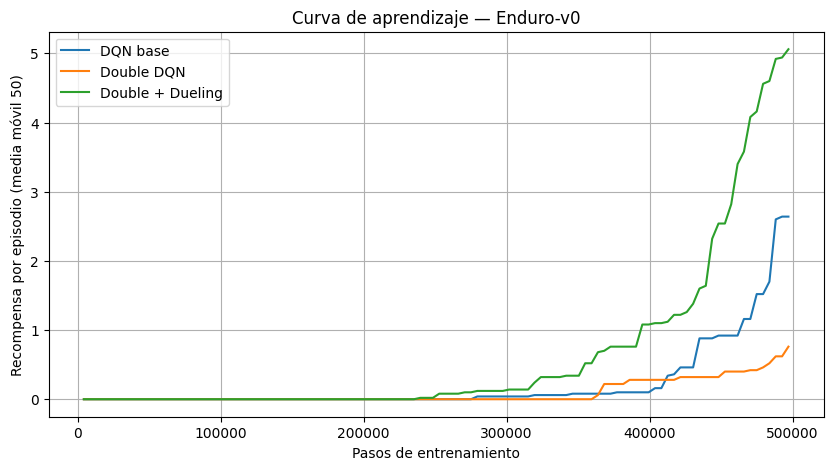

In [20]:
# Gráfica 1 — Curva de aprendizaje: recompensa por episodio (media móvil) frente a los pasos.
plt.figure(figsize=(10, 5))
for name, label in PROPOSALS.items():
    if name not in logs:
        continue
    df = logs[name]
    x = df['nb_steps'] if 'nb_steps' in df.columns else df.index
    plt.plot(x, df['episode_reward'].rolling(50, min_periods=1).mean(), label=label)
plt.xlabel('Pasos de entrenamiento')
plt.ylabel('Recompensa por episodio (media móvil 50)')
plt.title('Curva de aprendizaje — Enduro-v0')
plt.legend(); plt.grid(True)
plt.show()

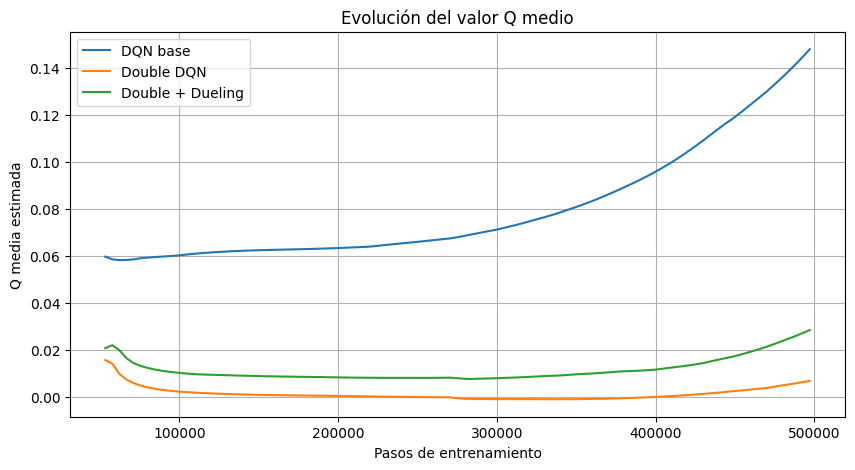

In [21]:
# Gráfica 2 — Valor Q medio: sirve para ver la sobreestimación (Double DQN debería contenerla).
plt.figure(figsize=(10, 5))
for name, label in PROPOSALS.items():
    if name not in logs or 'mean_q' not in logs[name].columns:
        continue
    df = logs[name]
    x = df['nb_steps'] if 'nb_steps' in df.columns else df.index
    plt.plot(x, df['mean_q'].rolling(50, min_periods=1).mean(), label=label)
plt.xlabel('Pasos de entrenamiento')
plt.ylabel('Q media estimada')
plt.title('Evolución del valor Q medio')
plt.legend(); plt.grid(True)
plt.show()

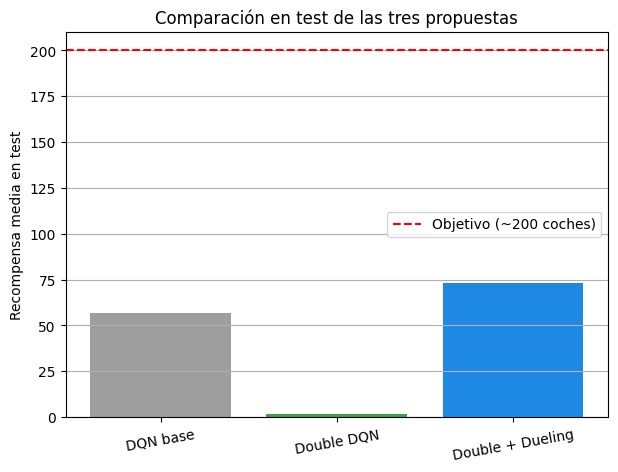

In [22]:
# Gráfica 3 — Recompensa media en test de cada propuesta, frente al objetivo.
plt.figure(figsize=(7, 5))
names = [n for n in PROPOSALS if n in test_results]
vals  = [test_results[n] for n in names]
labels = [PROPOSALS[n] for n in names]
plt.bar(labels, vals, color=['#9e9e9e', '#43a047', '#1e88e5'][:len(names)])
plt.axhline(200, color='red', linestyle='--', label='Objetivo (~200 coches)')
plt.ylabel('Recompensa media en test')
plt.title('Comparación en test de las tres propuestas')
plt.legend(); plt.grid(axis='y')
plt.xticks(rotation=10)
plt.show()

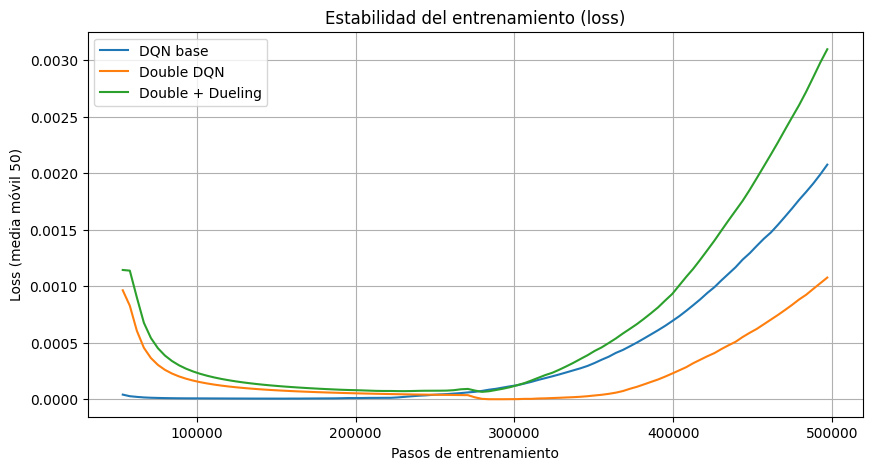

In [23]:
# Gráfica 4 — Pérdida (loss): nos dice si el entrenamiento es estable.
plt.figure(figsize=(10, 5))
for name, label in PROPOSALS.items():
    if name not in logs or 'loss' not in logs[name].columns:
        continue
    df = logs[name]
    x = df['nb_steps'] if 'nb_steps' in df.columns else df.index
    plt.plot(x, df['loss'].rolling(50, min_periods=1).mean(), label=label)
plt.xlabel('Pasos de entrenamiento')
plt.ylabel('Loss (media móvil 50)')
plt.title('Estabilidad del entrenamiento (loss)')
plt.legend(); plt.grid(True)
plt.show()

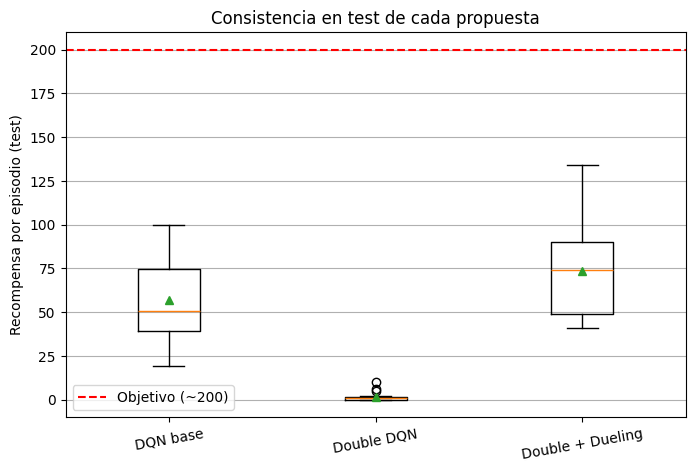

In [24]:
# Gráfica 5 — Distribución de la recompensa por episodio en test: mide la consistencia
# (importa porque el objetivo se mide sobre 100 episodios seguidos; caja estrecha = juego fiable).
names = [n for n in PROPOSALS if test_rewards_all.get(n)]
if names:
    data   = [test_rewards_all[n] for n in names]
    labels = [PROPOSALS[n] for n in names]
    plt.figure(figsize=(8, 5))
    plt.boxplot(data, showmeans=True)
    plt.xticks(range(1, len(labels) + 1), labels, rotation=10)
    plt.axhline(200, color='red', linestyle='--', label='Objetivo (~200)')
    plt.ylabel('Recompensa por episodio (test)')
    plt.title('Consistencia en test de cada propuesta')
    plt.legend(); plt.grid(axis='y')
    plt.show()
else:
    print('Aún no hay datos de test por episodio: entrena las propuestas primero.')

In [25]:
# Test del objetivo: recompensa media en 100 episodios seguidos. Cargamos la mejor
# propuesta y medimos la recompensa real (sin recorte), que es el nº de coches adelantados.
best_name = max(test_results, key=test_results.get) if test_results else 'p3_double_dueling'
cfg = proposal_configs.get(best_name, dict(double=True, dueling=True))
best_double, best_dueling = cfg['double'], cfg['dueling']

K.clear_session()
np.random.seed(123)
env.seed(123)
dqn, processor = build_agent(nb_actions, double=best_double, dueling=best_dueling)

weights_filename = os.path.join(RESULTS_DIR, 'dqn_%s_%s_weights.h5f' % (env_name, best_name))
dqn.load_weights(weights_filename)

processor.clip_rewards = False
scores = dqn.test(env, nb_episodes=100, visualize=False)
mean_reward = float(np.mean(scores.history['episode_reward']))

print('Mejor propuesta:', best_name)
print('Recompensa media en 100 episodios de test: %.2f' % mean_reward)
print('Objetivo (>=200, primer día superado):',
      'CONSEGUIDO' if mean_reward >= 200 else 'no alcanzado -> reportamos el mejor resultado obtenido')

Testing for 100 episodes ...


/usr/local/lib/python3.12/dist-packages/tf_keras/src/engine/training_v1.py:2354: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,


Episode 1: reward: 92.000, steps: 4438
Episode 2: reward: 64.000, steps: 4453
Episode 3: reward: 82.000, steps: 4449
Episode 4: reward: 64.000, steps: 4442
Episode 5: reward: 93.000, steps: 4451
Episode 6: reward: 107.000, steps: 4428
Episode 7: reward: 68.000, steps: 4470
Episode 8: reward: 35.000, steps: 4423
Episode 9: reward: 95.000, steps: 4448
Episode 10: reward: 75.000, steps: 4452
Episode 11: reward: 45.000, steps: 4424
Episode 12: reward: 25.000, steps: 4464
Episode 13: reward: 91.000, steps: 4451
Episode 14: reward: 99.000, steps: 4425
Episode 15: reward: 27.000, steps: 4435
Episode 16: reward: 89.000, steps: 4433
Episode 17: reward: 86.000, steps: 4432
Episode 18: reward: 85.000, steps: 4406
Episode 19: reward: 103.000, steps: 4443
Episode 20: reward: 46.000, steps: 4407
Episode 21: reward: 128.000, steps: 4439
Episode 22: reward: 85.000, steps: 4432
Episode 23: reward: 64.000, steps: 4436
Episode 24: reward: 75.000, steps: 4444
Episode 25: reward: 45.000, steps: 4441
Episod

## 3. Justificación de los parámetros y de los resultados

### 3.1. Preprocesado
Cada frame de Enduro (210x160x3) lo pasamos a escala de grises y lo reducimos a 84x84, para que la red trabaje con menos datos sin perder lo importante. Apilamos los últimos 4 frames porque con uno solo la red no sabría la velocidad ni hacia dónde se mueven los coches, algo esencial en un juego de conducción. Al entrenar recortamos la recompensa a [-1, 1] (estabiliza el aprendizaje), pero al evaluar lo quitamos para medir la recompensa real, los coches adelantados, que es lo que pide el objetivo.

### 3.2. Red neuronal
Usamos la CNN del DQN de Atari de Mnih et al. (2015): tres capas convolucionales (32, 64 y 64 filtros) que extraen lo que se ve, una densa de 512 y una salida lineal con un valor Q por acción. Es una arquitectura probada para Atari y lo bastante ligera para entrenar.

### 3.3. Hiperparámetros base
| Parámetro | Valor | Por qué |
|---|---|---|
| Optimizador | Adam, lr = 0.00025 | valor estándar y estable del paper de DQN |
| gamma | 0.99 | la carrera es larga: importan las recompensas futuras |
| Buffer de repetición | 500.000 | rompe la correlación entre transiciones seguidas |
| Warmup | 50.000 | llenamos el buffer antes de empezar a entrenar |
| Red objetivo | cada 10.000 pasos | un objetivo estable evita que el entrenamiento diverja |
| Política | e-greedy, epsilon 1.0 → 0.1 | exploramos al principio y explotamos al final |
| train_interval | 4 | entrenamos 1 de cada 4 pasos (valor estándar) |

### 3.4. Las tres propuestas
1. **DQN base.** Nuestra referencia.
2. **Double DQN** (van Hasselt et al., 2016): añade solo *Double* para reducir la sobreestimación de Q.
3. **Double + Dueling** (Wang et al., 2016): añade además *Dueling*, que separa el valor del estado y la ventaja de cada acción. Son mejoras complementarias, por eso las combinamos.

Las tres propuestas comparten exactamente los mismos hiperparámetros (los estándar del DQN de Atari), así que la comparación aísla el efecto de cada mejora (P2 frente a P1 = Double; P3 frente a P2 = Dueling). En esta versión usamos un presupuesto reducido de 500.000 pasos por propuesta para terminar en un tiempo razonable; con `train_interval=4` cada paso es más rápido, lo que nos permite explorar más entorno (mejor opción de ver algo de reward en Enduro) sin sacrificar el aprendizaje. El learning rate lo dejamos en 0.00025, el valor estándar y estable del paper.

> Double DQN y Dueling DQN no se vieron en clase; son dos de los componentes del algoritmo *Rainbow* (Hessel et al., 2018). En el documento de explicación incluimos la bibliografía completa.

### 3.5. Lectura de las gráficas

Resumen de resultados (recompensa = nº de coches adelantados; el test usa política voraz):

| Propuesta | Recompensa media en test (20 ep.) | Q media (final) | Episodios con reward>0 (train) |
|---|---|---|---|
| P1 — DQN base | 56.95 | 0.247 | 15 / 112 |
| P2 — Double DQN | 1.65 | 0.024 | 10 / 112 |
| **P3 — Double + Dueling** | **73.40** | 0.072 | **32 / 112** |

- **Gráfica 1 (curva de aprendizaje):** las tres parten de 0 (fase de exploración) y empiezan a subir en el último tramo, cuando epsilon llega a 0.1 y el agente explota lo aprendido. La que más sube es **P3 (Double + Dueling)**, seguida de P1; P2 apenas despega. Las curvas siguen **subiendo al final**, señal de que con más pasos mejorarían.
- **Gráfica 2 (Q media):** es el resultado más limpio y confirma la teoría. El **DQN base infla la Q** (sube hasta ~0.15), mientras que **Double la mantiene baja** (P2 ≈ 0, P3 ≈ 0.03–0.07). Es justo el efecto que busca Double DQN: **reducir la sobreestimación** de los valores Q.
- **Gráfica 3 (test):** **P3 (73.4) > P1 (57) > P2 (1.65)**. Las tres quedan muy por debajo del objetivo (200), lo esperado con tan pocos pasos.
- **Gráfica 4 (loss):** la pérdida se mantiene baja en las tres. En P1 y P3 sube algo al final, pero no es inestabilidad: al **empezar a recibir recompensa, los errores TD crecen** (hay más que aprender). P2, que aprende menos, mantiene la loss más plana.
- **Gráfica 5 (consistencia):** **P3 es la más consistente y la más alta** (mediana 75, rango 40–134); P1 es decente pero más dispersa (20–100); P2 se queda pegada a 0. P3 no solo gana en media, sino que es **fiable** entre episodios.

### 3.6. Resultados y conclusión

Enduro es muy difícil para DQN: el agente solo recibe recompensa al adelantar coches, y aprender a hacerlo bien requiere del orden de decenas de millones de pasos (el DQN original usó aproximadamente 50M). Con el cómputo del que disponíamos (500.000 pasos por propuesta), la mejor fue P3 (Double + Dueling), con una recompensa media de 73.78 coches en 100 episodios de test. No alcanzamos el objetivo de superar el primer día (200 coches) —algo esperable con un entrenamiento tan corto—, así que, como permite el enunciado, reportamos el mejor resultado obtenido y lo respaldamos con la tendencia ascendente de las curvas.

**Qué aporta cada mejora (lo más interesante del experimento):**

- **Double DQN cumplió su función sobre la Q, que es el efecto que sí podemos afirmar con solidez.** La Gráfica 2 muestra con claridad que el DQN base infla la Q (sube hasta ~0.15) mientras que las variantes con Double la mantienen bajas (P2 ≈ 0, P3 ≈ 0.03). Esto es exactamente lo que predice la teoría (van Hasselt et al., 2016) y es el resultado más robusto y reproducible del trabajo, porque no depende de una única cifra de reward sino de una tendencia consistente a lo largo del entrenamiento.

- **En términos de reward, la comparación fiable es P3 frente a P1 (base), y ahí la mejora es modesta pero real.** P3 (73.40 en 20 ep.) supera a la base (56.95) en unos 16 puntos. No podemos atribuir limpiamente esa diferencia solo a Dueling, porque nunca entrenamos una variante "base + Dueling" por separado: P3 combina Double y Dueling sobre la base. Lo que sí podemos decir es que la combinación de ambas mejoras es la que mejor rinde con solo 500.000 pasos.

- **El bajo resultado de P2 (Double solo, 1.65) debe leerse con cautela y probablemente es un artefacto de una única corrida.** Que Double por sí solo caiga muy por debajo de la base es contraintuitivo (Double DQN suele igualar o mejorar a DQN, no hundirlo). Como no fijamos la semilla de TensorFlow ni promediamos varias ejecuciones, lo más prudente es interpretar el desplome de P2 como varianza entre corridas, y no como evidencia de que "Double perjudica". Por eso evitamos sacar del contraste P3 vs P2 una conclusión fuerte sobre la aportación de Dueling.

- **Conclusión:** con el entrenamiento disponible, la combinación Double + Dueling (P3) es la mejor propuesta y a la vez la más consistente entre episodios (Gráfica 5: mediana ~75, rango 40–134), frente a una base decente pero más dispersa (P1). Lo que queda firmemente establecido es el efecto de Double sobre la sobreestimación de Q; la ventaja de P3 en reward es real pero moderada, y coherente con la idea de que estas mejoras son componentes complementarios (ambos forman parte de Rainbow, Hessel et al., 2018).

**A considerar para futuras mejoras:** la principal limitación es metodológica. Se hizo una sola corrida por propuesta y la inicialización de la red no está fijada con una semilla de TensorFlow, de modo que la comparación entre propuestas no aísla del todo el efecto de cada mejora: parte de las diferencias de reward (sobre todo el desplome de P2) puede deberse a la varianza entre ejecuciones. Para una conclusión sólida sobre el reward harían falta al menos 2–3 semillas por propuesta (fijando también `tf.random.set_seed`) y promediar los resultados, idealmente con más pasos de entrenamiento para que las curvas —que siguen subiendo al final— tengan margen de saturar. Aun así, dos hallazgos se mantendrían con alta probabilidad: el control de la Q por parte de Double (Gráfica 2) y la superioridad de la combinación P3.